# v0 — Data Audit ของ Model A (Piotroski / Fundamental)

**ทำอะไร:** ตรวจ "วัตถุดิบ" ทั้งหมดก่อนเริ่มทำ Model A จริง — รายชื่อสมาชิก S&P 500 ย้อนหลัง, งบการเงินจาก SEC (XBRL),
ราคาหุ้น (yfinance) และ benchmark แล้ววัดว่าแต่ละรอบ rebalance (สิ้นเดือน มิ.ย. ทุกปี) มีข้อมูลครบกี่เปอร์เซ็นต์

**ทำไม:** backtest ที่ข้อมูลรั่ว (มองอนาคต) หรือข้อมูลหายแบบมีอคติ จะให้ผลสวยเกินจริง
อุปมา: เหมือนเช็ควัตถุดิบในตู้เย็นก่อนทำอาหาร — ถ้าของหมดอายุหรือขาดไปครึ่งตู้ ทำอาหารอร่อยแค่ไหนก็กินไม่ได้

**อ่านผลอย่างไร:**
1. แต่ละหัวข้อจะมีตารางตัวเลขจริงจากการรัน (ไม่มีการเดา) ตามด้วยกราฟ
2. ตัวเลขที่ต้องดูที่สุดคือ **"% หุ้นที่ใช้ได้ต่อรอบ rebalance"** ในหัวข้อ 7 — ถ้าต่ำมากในบางช่วง ต้องหยุดถามผู้ใช้ก่อนไปต่อ
3. เซลล์สุดท้ายสรุปผล ข้อจำกัด และแยก "ทดสอบแล้ว" กับ "ยังเป็นแค่ไอเดีย"

**กติกา point-in-time ที่ใช้ (ผู้ใช้ยืนยันแล้วใน Phase 0):**
- ใช้วันยื่นงบจริง (`filed`) ไม่ใช่วันสิ้นงวด, งบจะ "ใช้ได้" ณ วัน R ก็ต่อเมื่อ filed ≤ R − 1 วัน
- ใช้ **ค่าที่ filed ครั้งแรก** (ไม่ใช้ตัวเลขที่ถูกแก้ย้อนหลังทีหลัง)
- รายชื่อสมาชิก ณ วัน R (ไม่ใช่รายชื่อปัจจุบัน)

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from lib import build_data, constituents, prices, audit, report, cik_map, checks, fscore
from lib.pit import PIT
from lib.paths import INTERIM
np.random.seed(42)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
report.banner()


> ⚠️ **คำเตือน survivorship bias (แสดงในทุก notebook)**
> รายชื่อสมาชิกมาจาก fja05680/sp500 (point-in-time) แต่ **ราคามาจาก yfinance ซึ่งเก็บเฉพาะหุ้นที่ยังซื้อขายอยู่**
> หุ้นที่ถูกซื้อกิจการ/ล้มละลาย/เปลี่ยนชื่อจำนวนหนึ่งจึงไม่มีราคา และหลุดออกจาก backtest
> ผลตอบแทนที่คำนวณได้จึงมีแนวโน้ม **สูงกว่าความจริง** (หุ้นที่ "ตาย" ไปมักเป็นหุ้นที่ผลตอบแทนแย่)
> สัดส่วนที่ขาดหายวัดไว้ใน `v0_data_audit.ipynb`

> ⚠️ **ข้อจำกัดของ held-out**: held-out = rebalance มิ.ย. 2023, 2024, 2025 (3 รอบเต็ม) + มิ.ย. 2026 ที่ถือได้แค่ ~3 เดือน
> (รอบ 2026 เป็นข้อมูลประกอบ ไม่นับตัดสิน) — มีแค่ 2–3 รอบ rebalance ที่ใช้ตัดสิน ผลช่วงนี้จึงมีความไม่แน่นอนสูงมาก
> ใช้เป็นการตรวจทิศทางเท่านั้น ไม่ใช่หลักฐานทางสถิติ


## 0) เตรียมข้อมูล (ใช้ cache — ครั้งแรกดาวน์โหลดจาก SEC/GitHub/Yahoo, ครั้งต่อไปอ่านจากไฟล์)

In [2]:
build_data.run()
hist = constituents.load_history()
spells = build_data.build_spells()
cmap = build_data.build_cik_map(spells)          # diagnostic ต่อ spell (วิธีแรก)
segs = build_data.build_segments(spells)         # ตัวที่ใช้จริง: CIK ต่อช่วงเวลา
long, wide = build_data.build_facts(segs)
pit = PIT(long)                                  # point-in-time accessor (เลือก tag ทีละ field เฉพาะที่ filed แล้ว)
adj, close, splits = prices.load_adj_close(), prices.load_close(), prices.load_splits()
pstatus = prices.load_status()
print("constituent rows:", len(hist), "| spells:", len(spells), "| cik segments:", len(segs))
print("annual facts (long):", len(long), "| company-years:", len(wide), "| companies:", wide.cik.nunique())
print("price matrix:", adj.shape, adj.index.min().date(), "→", adj.index.max().date())

SEC RSS: 210 เดือน, 424,287 filings (cache: /Users/boeing/Desktop/SNP-claude/model_A/data/raw/sec/xbrlrss_parsed)


constituent rows: 2720 | spells: 1262 | cik segments: 922
annual facts (long): 178703 | company-years: 13467 | companies: 812
price matrix: (4887, 1151) 2008-01-01 → 2026-09-25


## 1) รายชื่อสมาชิก S&P 500 ย้อนหลัง (fja05680/sp500)

ช่วงข้อมูล: 1996-01-02 → 2026-08-18 (2720 วันที่มีการเปลี่ยนแปลง)
จำนวนสมาชิกต่อวัน (ตั้งแต่ 2009):
count    1235.0
mean      500.9
std         3.7
min       496.0
25%       497.0
50%       499.0
75%       505.0
max       507.0

spell (ช่วงเป็นสมาชิก) ที่ทับช่วง 2009+ : 894 spell, 869 ticker

จำนวน ticker ที่เข้า/ออกต่อปี:
         2009  2010  2011  2012  2013  2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025  2026
added      29    14    19    18    19    16    30    31    27    24    29    20    21    22    19    20    21    17
removed    28    16    19    18    19    14    27    27    28    24    29    20    21    24    19    20    21    17


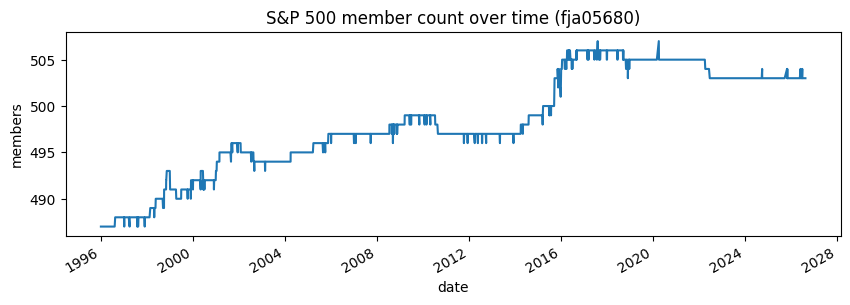

In [3]:
n = hist.set_index("date")["tickers"].str.len()
print(f"ช่วงข้อมูล: {hist.date.min().date()} → {hist.date.max().date()} ({len(hist)} วันที่มีการเปลี่ยนแปลง)")
print("จำนวนสมาชิกต่อวัน (ตั้งแต่ 2009):"); print(n[n.index >= "2009-01-01"].describe().round(1).to_string())
sp09 = spells[(spells.end.isna()) | (spells.end >= "2009-01-01")]
print(f"\nspell (ช่วงเป็นสมาชิก) ที่ทับช่วง 2009+ : {len(sp09)} spell, {sp09.ticker.nunique()} ticker")
chg = pd.DataFrame({"added": sp09[sp09.start >= "2009-01-01"].start.dt.year.value_counts(),
                    "removed": sp09.end.dropna().dt.year.value_counts()}).fillna(0).astype(int).sort_index()
print("\nจำนวน ticker ที่เข้า/ออกต่อปี:"); print(chg.T.to_string())
ax = n.plot(figsize=(10, 3), title="S&P 500 member count over time (fja05680)"); ax.set_ylabel("members"); plt.show()

## 2) จับคู่ ticker → SEC CIK แบบรู้เวลา
ticker = "เลขที่บ้าน" (เปลี่ยนเจ้าของได้), CIK = "เลขบัตรประชาชน" ของบริษัท

**2.1 วิธีแรก (majority ต่อ spell)** — เก็บไว้เป็น diagnostic เพราะเจอปัญหา 2 แบบ: prefix ชนกับบริษัทอื่น และบริษัทที่ปรับโครงสร้าง
(ตั้ง holding company ใหม่ → CIK เปลี่ยนกลาง spell) จึงพัฒนาเป็นวิธีที่ 2

In [4]:
print(cmap.method.value_counts().to_string())
print(f"conflict กับ SEC ticker ปัจจุบัน: {int(cmap.conflict.sum())} spell")

method
rss          839
unmatched     40
current       15
conflict กับ SEC ticker ปัจจุบัน: 20 spell


**2.2 วิธีที่ใช้จริง: segment รายปี + override ที่มีหลักฐาน** (ดู docstring ของ `lib/cik_map.py`)
- `auto` = CIK เดียวทั้ง spell, `auto_multi` = CIK เปลี่ยนกลาง spell (เช่น reorganization), `override` = ตัดสินด้วยหลักฐานจาก SEC submissions (`lib/cik_overrides.csv`)

In [5]:
print(segs.method.value_counts().to_string())
sp_status = segs.groupby(["ticker","start"]).cik.apply(lambda s: s.notna().any())
print(f"\nspell ที่จับคู่ได้: {sp_status.sum()}/{len(sp_status)} ({sp_status.mean():.1%})")
print("\noverride ทั้งหมด (พร้อมหลักฐาน):")
display(segs[segs.method=="override"][["ticker","valid_from","valid_to","cik","confidence","evidence"]])
print("\nspell ที่ CIK เปลี่ยนกลางทาง (auto_multi):")
display(segs[segs.method=="auto_multi"][["ticker","start","end","cik","valid_from","valid_to"]])
um = segs[segs.cik.isna()].copy()
um["days_2009plus"] = ((um.end.fillna(pd.Timestamp.today()) - um.start.clip(lower=pd.Timestamp("2009-01-01"))).dt.days)
print(f"\nunmatched: {len(um)} spell (เรียงตามจำนวนวันที่เป็นสมาชิกหลังปี 2009):")
display(um.sort_values("days_2009plus", ascending=False)[["ticker","start","end","days_2009plus"]])

method
auto          790
unmatched      61
auto_multi     41
override       30

spell ที่จับคู่ได้: 833/894 (93.2%)

override ทั้งหมด (พร้อมหลักฐาน):


,ticker,valid_from,valid_to,cik,confidence,evidence
61,APA,1997-07-28,2022-02-21,6769.0,high,Apache Corp; APA Corp holdco (1841666) first 1...
62,APA,2022-02-22,NaT,1841666.0,high,APA Corp holdco first 10-K 2022-02-22 (SEC RSS)
95,BBT,1997-12-04,2019-12-08,92230.0,high,SEC formerNames of 92230 = BB&T CORP; current ...
116,BLK,2011-04-04,2025-02-24,1364742.0,high,SEC formerNames of 1364742 = BlackRock Inc.; n...
117,BLK,2025-02-25,NaT,2012383.0,high,new BlackRock Inc. holdco first 10-K 2025-02-2...
126,BRK.B,2010-02-16,NaT,1067983.0,high,XBRL prefix 'brk' belongs to BRK Inc./Gen 2 Te...
170,CI,1996-01-02,2019-02-27,701221.0,high,SEC formerNames of 701221 = CIGNA CORP; new Ci...
171,CI,2019-02-28,NaT,1739940.0,high,Cigna Group holdco first 10-K 2019-02-28 (SEC ...
206,CPT,2022-04-04,NaT,906345.0,high,prefix 'cpt' also used by Copper Property CTL ...
207,CPWR,1999-01-04,2012-01-02,859014.0,high,Compuware Corp = 859014; current CPWR ticker (...



spell ที่ CIK เปลี่ยนกลางทาง (auto_multi):


,ticker,start,end,cik,valid_from,valid_to
26,AGN,1996-01-02,2020-05-11,850693.0,1996-01-02,2016-02-25
27,AGN,1996-01-02,2020-05-11,1578845.0,2016-02-26,2020-05-11
79,AVGO,2014-05-08,NaT,1441634.0,2014-05-08,2016-12-22
80,AVGO,2014-05-08,NaT,1649338.0,2016-12-23,2018-12-20
81,AVGO,2014-05-08,NaT,1730168.0,2018-12-21,NaT
104,BG,2023-03-15,NaT,1144519.0,2023-03-15,2024-02-21
105,BG,2023-03-15,NaT,1996862.0,2024-02-22,NaT
142,CB,1996-01-02,NaT,20171.0,1996-01-02,2016-02-25
143,CB,1996-01-02,NaT,896159.0,2016-02-26,NaT
149,CCE,1998-10-08,2016-05-30,804055.0,1998-10-08,2011-02-13



unmatched: 61 spell (เรียงตามจำนวนวันที่เป็นสมาชิกหลังปี 2009):


,ticker,start,end,days_2009plus
908,XL,2001-09-04,2018-09-11,3540
903,WYND,2006-08-01,2018-05-30,3436
1,AABA,1999-12-08,2017-06-18,3090
253,DISCK,2014-08-07,2022-04-10,2803
274,DXC,1996-01-02,2015-11-30,2524
...,...,...,...,...
329,FCPT,2015-11-10,2015-11-16,6
850,UST,1996-01-02,2009-01-05,4
601,NCC,1996-01-02,2009-01-01,0
552,MER,1996-01-02,2009-01-01,0


### 2.3 สุ่มตรวจความถูกต้อง (ชื่อบริษัทจาก SEC เทียบกับ ticker) — ตรวจด้วยตา

In [6]:
from lib import sec_rss
rss = sec_rss.load_all()
name_of = rss.sort_values("filed").groupby("cik").name.last()
sic_of = rss.sort_values("filed").dropna(subset=["sic"]).groupby("cik").sic.last().to_dict()
chk_ = segs.dropna(subset=["cik"]).sample(30, random_state=42).assign(sec_name=lambda d: d.cik.astype(int).map(name_of))
display(chk_[["ticker","valid_from","valid_to","cik","sec_name","method"]])

,ticker,valid_from,valid_to,cik,sec_name,method
767,SPLS,1998-10-07,2017-09-12,791519.0,STAPLES INC,auto
648,PARA,2022-02-17,2025-08-07,813828.0,Paramount Global,override
126,BRK.B,2010-02-16,NaT,1067983.0,BERKSHIRE HATHAWAY INC,override
226,CVH,2005-08-30,2013-05-06,1054833.0,COVENTRY HEALTH CARE INC,auto
407,HCP,2008-03-31,2019-11-04,765880.0,"HEALTHPEAK PROPERTIES, INC.",auto
872,VTRS,2020-11-17,NaT,1792044.0,Viatris Inc,auto
616,NOC,1996-01-02,NaT,1133421.0,NORTHROP GRUMMAN CORP /DE/,auto
289,EMC,1996-03-28,2016-09-06,790070.0,EMC CORP,auto
596,MYL,2004-04-23,2016-02-15,69499.0,MYLAN INC.,auto_multi
882,WEC,2008-10-31,NaT,783325.0,"WEC ENERGY GROUP, INC.",auto


### 2.4 ตรวจขนาดบริษัท (sanity check อัตโนมัติ)
สมาชิก S&P 500 ควรเป็นบริษัทใหญ่ ถ้า CIK ที่จับคู่ได้มี total assets ต่ำกว่า $500M ในงบล่าสุดของช่วงนั้น → น่าสงสัยว่าจับคู่ผิดบริษัท

In [7]:
ta_ = wide[["cik","period_end","total_assets"]].dropna()
def seg_assets(r):
    x = ta_[(ta_.cik == r.cik) & (ta_.period_end >= r.valid_from - pd.Timedelta(days=400)) &
            (ta_.period_end <= (r.valid_to if pd.notna(r.valid_to) else pd.Timestamp.today()))]
    return x.total_assets.median() if len(x) else np.nan
sz = segs.dropna(subset=["cik"]).copy(); sz["cik"] = sz.cik.astype(int)
sz["median_assets_bn"] = sz.apply(seg_assets, axis=1) / 1e9
sz["sec_name"] = sz.cik.map(name_of)
small = sz[sz.median_assets_bn < 0.5]
print(f"segment ที่ median total assets < $0.5B: {len(small)} | ไม่มีข้อมูล assets เลย: {sz.median_assets_bn.isna().sum()}")
display(small[["ticker","valid_from","valid_to","cik","sec_name","median_assets_bn","method"]])
display(sz[sz.median_assets_bn.isna()][["ticker","valid_from","valid_to","cik","sec_name","method"]].head(30))

segment ที่ median total assets < $0.5B: 0 | ไม่มีข้อมูล assets เลย: 1


,ticker,valid_from,valid_to,cik,sec_name,median_assets_bn,method


,ticker,valid_from,valid_to,cik,sec_name,method
657,PCL,2002-01-17,2016-02-21,849213,PLUM CREEK TIMBER CO INC,auto


## 3) ปีเริ่มต้นจริงของข้อมูล XBRL
ผู้ใช้ขอให้รายงาน "ปีเริ่มต้นจริง" — วัดจากวันที่ filed ครั้งแรกของงบรายปี (10-K) ที่มี total assets ของแต่ละบริษัท

In [8]:
ta = long[long.field == "total_assets"]
first_10k = ta.groupby("cik").filed.min()
print("filed ครั้งแรกที่เร็วที่สุด:", first_10k.min().date())
print("\nจำนวนบริษัทตามปีที่ยื่นงบ XBRL รายปีครั้งแรก:")
print(first_10k.dt.year.value_counts().sort_index().to_string())
# period_end เก่าที่สุดที่ปรากฏ (รวมตัวเลขเปรียบเทียบปีก่อนในงบ)
print("\nperiod_end เก่าที่สุดของ total_assets:", ta.period_end.min().date())

filed ครั้งแรกที่เร็วที่สุด: 2009-05-29

จำนวนบริษัทตามปีที่ยื่นงบ XBRL รายปีครั้งแรก:
filed
2009     29
2010    377
2011    227
2012     47
2013     19
2014     12
2015     19
2016     10
2017      9
2018     12
2019      9
2020      9
2021      6
2022      7
2023      2
2024      8
2025      6
2026      3

period_end เก่าที่สุดของ total_assets: 2006-12-31


## 4) ตรวจ point-in-time
**4.1 lag ระหว่างวันสิ้นงวดบัญชี กับวันที่ยื่นจริง** (ถ้าใช้วันสิ้นงวดแทนวันยื่น = มองอนาคตไปเท่ากับ lag นี้)
หมายเหตุ: ใช้ `filed_max` = วันที่ field สุดท้ายของแถวถูกเปิดเผย (ค่า lag ยาวมาก = field บางตัวเพิ่งมีใน 10-K ปีถัด ๆ ไปเป็นตัวเลขเปรียบเทียบ)
ตอนใช้งานจริง PIT จะเลือกทีละ field จึงไม่เสียข้อมูลจาก lag ยาวเหล่านี้

count    13467.0
mean       308.0
std        352.0
min       -275.0
5%          39.0
25%         51.0
50%         59.0
75%        425.0
95%       1145.0
99%       1156.0
max       1884.0

% ที่ lag > 90 วัน: 41.5%  |  > 365 วัน (เป็นค่าที่มาจากงบปีถัดไป เพราะงบปีนั้นยังไม่เป็น XBRL): 40.1%


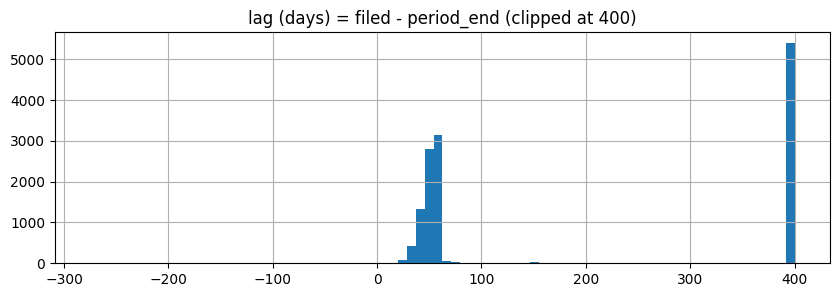

In [9]:
lag = (wide.filed_max - wide.period_end).dt.days
print(lag.describe(percentiles=[.05,.25,.5,.75,.95,.99]).round(0).to_string())
print(f"\n% ที่ lag > 90 วัน: {(lag > 90).mean():.1%}  |  > 365 วัน (เป็นค่าที่มาจากงบปีถัดไป เพราะงบปีนั้นยังไม่เป็น XBRL): {(lag > 365).mean():.1%}")
lag.clip(upper=400).hist(bins=80, figsize=(10,3)); plt.title("lag (days) = filed - period_end (clipped at 400)"); plt.show()

**4.2 ทำไมต้องใช้ค่าที่ filed ครั้งแรก** — วัดว่ามีการแก้ตัวเลขย้อนหลัง (restatement/reclassification) บ่อยแค่ไหน

In [10]:
x = long[long.field != "shares_cover"].dropna(subset=["val_last"])
x = x.assign(changed=(x.val != x.val_last) & (x.filed_last > x.filed))
rel = ((x.val_last - x.val).abs() / x.val.abs().replace(0, np.nan))
res = x.assign(rel=rel).groupby("field").agg(n=("changed","size"), pct_changed=("changed","mean"),
        median_rel_change_if_changed=("rel", lambda s: s[x.loc[s.index,"changed"]].median()))
res["pct_changed"] = (res.pct_changed*100).round(1); res["median_rel_change_if_changed"] = (res.median_rel_change_if_changed*100).round(2)
print("pct_changed = % ของ (บริษัท, field, งวด) ที่ค่าล่าสุดต่างจากค่าที่ filed ครั้งแรก | median_rel_change = % เปลี่ยน (median)")
display(res)

pct_changed = % ของ (บริษัท, field, งวด) ที่ค่าล่าสุดต่างจากค่าที่ filed ครั้งแรก | median_rel_change = % เปลี่ยน (median)


,n,pct_changed,median_rel_change_if_changed
field,,,
cfo,14249,14.0,1.28
cogs,9742,16.4,1.60
current_assets,9869,10.4,0.91
current_liabilities,9852,9.4,0.44
equity,20129,9.6,0.35
gross_profit,4945,18.3,0.84
interest_expense,12081,10.1,1.50
lt_debt,15694,7.7,0.53
net_income,23791,8.8,0.76


## 5) ราคาหุ้น (yfinance, Adj Close ปรับ split+dividend)
หัวข้อนี้วัด **ข้อมูลดิบ** จาก ticker ตามรายชื่อ fja เท่านั้น — หัวข้อ 7 จะเพิ่มการหาราคาผ่าน ticker ปัจจุบันของ CIK
(กรณีบริษัทเปลี่ยนชื่อ เช่น FB → META) และตรวจ ticker reuse ด้วยราคาจริง/market cap

In [11]:
sp09y = sp09.assign(yahoo=sp09.ticker.map(constituents.to_yahoo))
st = pstatus.set_index("yahoo").n_days
sp09y["has_price"] = sp09y.yahoo.map(st).fillna(0) > 0
print(f"spell ที่ทับช่วง 2009+: {len(sp09y)} | มีราคาจาก yfinance: {sp09y.has_price.sum()} ({sp09y.has_price.mean():.1%})")
still = sp09y.end.isna()
print(f"  - ยังเป็นสมาชิก ณ ข้อมูลล่าสุด: {sp09y[still].has_price.mean():.1%} มีราคา ({still.sum()} spell)")
print(f"  - ออกจากดัชนีไปแล้ว:           {sp09y[~still].has_price.mean():.1%} มีราคา ({(~still).sum()} spell)")
print("\n% spell ที่ออกจากดัชนีแล้วมีราคา แยกตามปีที่ออก:")
print(sp09y[~still].groupby(sp09y[~still].end.dt.year).has_price.agg(["size","mean"]).round(2).T.to_string())

spell ที่ทับช่วง 2009+: 894 | มีราคาจาก yfinance: 670 (74.9%)
  - ยังเป็นสมาชิก ณ ข้อมูลล่าสุด: 100.0% มีราคา (503 spell)
  - ออกจากดัชนีไปแล้ว:           42.7% มีราคา (391 spell)

% spell ที่ออกจากดัชนีแล้วมีราคา แยกตามปีที่ออก:
end    2009   2010   2011   2012   2013   2014   2015   2016   2017   2018   2019  2020   2021   2022   2023  2024   2025   2026
size  28.00  16.00  19.00  18.00  19.00  14.00  27.00  27.00  28.00  24.00  29.00  20.0  21.00  24.00  19.00  20.0  21.00  17.00
mean   0.43   0.25   0.21   0.33   0.47   0.43   0.22   0.48   0.46   0.29   0.48   0.4   0.52   0.29   0.58   0.6   0.62   0.65


**5.1 ticker reuse / ราคาเริ่มหลังเข้าดัชนี** — ถ้าราคาจาก Yahoo เริ่ม "หลัง" วันที่เข้าดัชนีนานมาก อาจเป็นราคาของบริษัทอื่นที่ใช้ ticker เดียวกันในปัจจุบัน

In [12]:
first_px = adj.apply(lambda s: s.first_valid_index())
last_px = adj.apply(lambda s: s.last_valid_index())
chk = sp09y[sp09y.has_price].copy()
chk["px_first"] = chk.yahoo.map(first_px); chk["px_last"] = chk.yahoo.map(last_px)
chk["gap_start_days"] = (chk.px_first - chk.start.clip(lower=pd.Timestamp("2008-01-02"))).dt.days
sus = chk[chk.gap_start_days > 30].sort_values("gap_start_days", ascending=False)
print(f"spell ที่ราคาเริ่มช้ากว่าวันเข้าดัชนี > 30 วัน: {len(sus)} (สงสัย ticker reuse หรือ Yahoo เก็บไม่ครบ)")
display(sus[["ticker","start","end","px_first","px_last","gap_start_days"]].head(30))
ended = chk[chk.end.notna()].copy()
ended["ends_before_exit"] = ended.px_last < ended.end - pd.Timedelta(days=30)
print(f"spell ที่ออกแล้วแต่ราคาหยุดก่อนวันออก > 30 วัน: {ended.ends_before_exit.sum()}")

spell ที่ราคาเริ่มช้ากว่าวันเข้าดัชนี > 30 วัน: 47 (สงสัย ticker reuse หรือ Yahoo เก็บไม่ครบ)


,ticker,start,end,px_first,px_last,gap_start_days
410,EQR,2001-12-03,2026-08-17,2026-08-17,2026-08-17,6802
108,AVB,2007-01-10,2026-08-17,2026-08-14,2026-08-14,6799
379,EA,2002-07-22,2026-08-04,2026-08-04,2026-08-04,6789
126,BBBY,1999-10-01,2017-07-25,2026-07-17,2026-09-25,6771
681,LEG,1999-10-18,2021-12-19,2026-07-17,2026-08-27,6771
82,APC,1997-07-28,2019-08-08,2026-02-12,2026-09-25,6616
1018,SGP,1996-01-02,2009-11-03,2026-02-06,2026-09-25,6610
1049,SPLS,1998-10-07,2017-09-12,2026-01-16,2026-09-25,6589
947,Q,2000-07-06,2011-03-31,2025-10-27,2026-09-25,6508
922,POM,2007-11-09,2016-03-23,2025-10-08,2026-09-25,6489


spell ที่ออกแล้วแต่ราคาหยุดก่อนวันออก > 30 วัน: 0


**5.2 outlier ของผลตอบแทนรายวัน** (ยังไม่ตัดออก — แค่นับและแสดงให้เห็น จะตัดสินใจใน v1)

In [13]:
ret = adj.pct_change(fill_method=None)
big_up, big_dn = (ret > 1.0), (ret < -0.5)
print(f"จุดข้อมูลผลตอบแทนรายวันทั้งหมด: {int(ret.notna().sum().sum()):,}")
print(f"  > +100%/วัน: {int(big_up.sum().sum())} จุด ใน {int(big_up.any().sum())} ticker")
print(f"  < −50%/วัน:  {int(big_dn.sum().sum())} จุด ใน {int(big_dn.any().sum())} ticker")
ev = ret.where(big_up | big_dn).stack().rename("ret").reset_index().rename(columns={"level_1":"yahoo"})
display(ev.sort_values("ret").head(15))

จุดข้อมูลผลตอบแทนรายวันทั้งหมด: 3,121,433
  > +100%/วัน: 143 จุด ใน 21 ticker
  < −50%/วัน:  150 จุด ใน 27 ticker


,Date,Ticker,ret
201,2020-03-19,^IRX,-10.333334
203,2020-03-30,^IRX,-1.224138
215,2021-02-23,AMCCF,-1.070373
249,2024-06-14,PCG-PB,-1.000000
213,2021-02-17,AMCCF,-0.999974
229,2021-05-26,AMCCF,-0.999908
177,2017-11-07,WFCNP,-0.999111
223,2021-03-23,AMCCF,-0.997796
256,2024-12-27,CPWR,-0.988889
261,2025-02-27,WFCNP,-0.984267


## 6) Benchmark (พร้อมหน่วยสกุลเงิน)
ผู้ใช้ขอ SPY, equal-weight, ^DJI, ^SET.BK — **Yahoo ไม่มีประวัติของ ^SET.BK** (ได้แค่ 1 วันล่าสุด) จึงเสนอ proxy ไว้ให้ตัดสิน

In [14]:
bm = pd.DataFrame([
 ("SPY","SPDR S&P 500 ETF (total return ผ่าน Adj Close)","USD"),
 ("RSP","Invesco S&P 500 Equal Weight ETF (เทียบกับ EW ที่สร้างเองจาก universe)","USD"),
 ("^GSPC","S&P 500 index (price only)","USD (index pts)"),
 ("^DJI","Dow Jones Industrial Average (price only)","USD (index pts)"),
 ("^SET.BK","SET Index","THB (index pts)"),
 ("TDEX.BK","ThaiDEX SET50 ETF — proxy ของ SET","THB"),
 ("THD","iShares MSCI Thailand ETF — proxy ของ SET ในหน่วย USD","USD"),
 ("THB=X","อัตราแลกเปลี่ยน USD/THB (ใช้แปลงหน่วย)","THB per USD"),
], columns=["ticker","description","currency"])
bm["first"] = bm.ticker.map(first_px).dt.date; bm["last"] = bm.ticker.map(last_px).dt.date
bm["n_days"] = bm.ticker.map(st)
display(bm)

,ticker,description,currency,first,last,n_days
0,SPY,SPDR S&P 500 ETF (total return ผ่าน Adj Close),USD,2008-01-02,2026-09-25,4713
1,RSP,Invesco S&P 500 Equal Weight ETF (เทียบกับ EW ...,USD,2008-01-02,2026-09-25,4713
2,^GSPC,S&P 500 index (price only),USD (index pts),2008-01-02,2026-09-25,4713
3,^DJI,Dow Jones Industrial Average (price only),USD (index pts),2008-01-02,2026-09-25,4713
4,^SET.BK,SET Index,THB (index pts),2026-09-25,2026-09-25,1
5,TDEX.BK,ThaiDEX SET50 ETF — proxy ของ SET,THB,2008-01-02,2026-09-24,4565
6,THD,iShares MSCI Thailand ETF — proxy ของ SET ในหน...,USD,2008-04-01,2026-09-25,4652
7,THB=X,อัตราแลกเปลี่ยน USD/THB (ใช้แปลงหน่วย),THB per USD,2008-01-01,2026-09-25,4859


## 7) ความครบของข้อมูลต่อรอบ rebalance (หัวข้อสำคัญที่สุด)
ทุกวันทำการสุดท้ายของ มิ.ย. — นับสมาชิก ณ วันนั้น แล้วดูว่ามี CIK / ราคา / งบรายปีล่าสุด / field ครบสำหรับ F-score 9 ข้อ / BM ratio ไหม
- `fscore_complete` = ครบทุก field ที่ F-score ต้องใช้ (รวม t-2 ของ total assets)
- `fscore_complete_ltd0` = เหมือนกัน แต่ถ้าไม่มี tag หนี้ระยะยาว ให้ถือว่า = 0 (สมมติฐานที่ต้องให้ผู้ใช้ตัดสิน)
- `has_price_R` = มีราคาที่ผ่านการตรวจ market cap (ราคาจริง × จำนวนหุ้นจาก SEC ≥ $1B) จาก ticker ตาม fja หรือ ticker ปัจจุบันของ CIK
- `bm_complete` = มี equity + จำนวนหุ้น + market cap ณ R
- `usable` = มี CIK + ราคา ณ R + F-score ครบ (แบบ ltd0) + BM ครบ

In [15]:
Rs = audit.rebalance_dates(adj["SPY"].dropna().index, range(2009, 2027))
cur = cik_map.load_current_map(); inv = {}
for tk, c in cur.items(): inv.setdefault(c, []).append(tk)
cik_ticker = {c: audit.common_ticker(v) for c, v in inv.items()}
panel = audit.build_panel(hist, segs, pit, adj, close, splits, Rs, constituents.to_yahoo, sic_of, cik_ticker,
                          prices.split_factor_after)
panel["usable"] = panel.has_cik & panel.has_price_R & panel.fscore_complete_ltd0 & panel.bm_complete
# assertion กันบั๊กเงียบ (ผู้ใช้ขอหลัง v0 รอบแรก): จำนวนสมาชิกต่อรอบ และงบ/ราคาต้องไม่ตกผิดปกติตั้งแต่ 2012
checks.members_per_R(panel)
checks.no_sudden_drop(panel, "has_fy_t", mask=~panel.financial)
checks.no_sudden_drop(panel, "has_price_R")
checks.no_sudden_drop(panel, "usable", mask=~panel.financial)
print("assertions ผ่านทั้งหมด")
panel.to_parquet(INTERIM / "v0_panel.parquet", index=False)
cols = ["has_cik","has_price_R","has_fy_t","fscore_complete","fscore_complete_ltd0","bm_complete","usable"]
cov = panel.groupby("R")[cols].mean().mul(100).round(1)
cov.insert(0, "members", panel.groupby("R").size())
cov.index = cov.index.date
print("% ของสมาชิก ณ แต่ละรอบ rebalance (ทุก sector):"); display(cov)
src = panel.pivot_table(index="R", columns="price_flag", values="ticker", aggfunc="count", fill_value=0)
src["via_cik_ticker"] = panel[panel.price_src == "cik"].groupby("R").size()
src.index = src.index.date
print("ผลตรวจราคาต่อรอบ (จำนวนหุ้น): ok = ผ่าน | ok_no_shares = มีราคาแต่ไม่มีจำนวนหุ้น | ok_shares_suspect = จำนวนหุ้น 2 แหล่งขัดกัน (ไม่ใช้คำนวณ market cap)")
print("penny_* / mcap_small_* = ราคาน่าจะเป็นของบริษัทอื่นที่ใช้ ticker ซ้ำ → ตัดออก | via_cik_ticker = ได้ราคาจาก ticker ปัจจุบันของ CIK")
display(src.fillna(0).astype(int))
print("รายการที่ถูกตัด (ticker reuse) และที่จำนวนหุ้นขัดกัน:")
display(panel[panel.price_flag.str.startswith(("penny","mcap")) | (panel.price_flag == "ok_shares_suspect")]
        [["R","ticker","yahoo","raw_price","shares_t","shares_ratio","price_flag"]].drop_duplicates("ticker"))

assertions ผ่านทั้งหมด
% ของสมาชิก ณ แต่ละรอบ rebalance (ทุก sector):


,members,has_cik,has_price_R,has_fy_t,fscore_complete,fscore_complete_ltd0,bm_complete,usable
2009-06-30,499,92.8,66.1,0.2,0.0,0.0,0.0,0.0
2010-06-30,499,96.4,68.9,66.3,0.8,1.2,48.7,0.8
2011-06-30,497,97.8,69.6,93.2,31.0,38.2,65.4,27.2
2012-06-29,497,98.4,72.4,96.8,46.5,55.1,69.8,39.4
2013-06-28,497,99.0,74.0,97.2,48.5,57.1,71.6,42.9
2014-06-30,498,99.0,75.7,97.4,50.4,57.2,73.5,43.2
2015-06-30,499,99.0,77.6,98.0,51.3,57.7,75.8,44.9
2016-06-30,505,99.2,81.4,98.8,51.7,57.4,79.8,47.5
2017-06-30,506,99.4,84.4,98.6,52.8,57.7,81.8,48.8
2018-06-29,506,99.6,86.4,98.8,52.8,57.9,84.0,51.0


ผลตรวจราคาต่อรอบ (จำนวนหุ้น): ok = ผ่าน | ok_no_shares = มีราคาแต่ไม่มีจำนวนหุ้น | ok_shares_suspect = จำนวนหุ้น 2 แหล่งขัดกัน (ไม่ใช้คำนวณ market cap)
penny_* / mcap_small_* = ราคาน่าจะเป็นของบริษัทอื่นที่ใช้ ticker ซ้ำ → ตัดออก | via_cik_ticker = ได้ราคาจาก ticker ปัจจุบันของ CIK


price_flag,mcap_small_fja,no_price,ok,ok_no_shares,ok_shares_suspect,penny_fja,via_cik_ticker
2009-06-30,0,167,0,330,0,2,19
2010-06-30,0,153,244,97,3,2,20
2011-06-30,0,149,324,20,2,2,21
2012-06-29,0,137,347,10,3,0,21
2013-06-28,1,128,355,11,2,0,20
2014-06-30,1,120,365,10,2,0,23
2015-06-30,1,111,377,7,3,0,23
2016-06-30,0,94,403,6,2,0,27
2017-06-30,0,79,414,12,1,0,29
2018-06-29,0,69,425,11,1,0,31


รายการที่ถูกตัด (ticker reuse) และที่จำนวนหุ้นขัดกัน:


,R,ticker,yahoo,raw_price,shares_t,shares_ratio,price_flag
112,2009-06-30,CPWR,None,0.105000,NaN,NaN,penny_fja
160,2009-06-30,EP,None,0.060000,NaN,NaN,penny_fja
569,2010-06-30,BRK.B,BRK-B,79.690002,1.103764e+06,NaN,ok_shares_suspect
902,2010-06-30,SII,SII,3.280000,2.484121e+08,NaN,ok_shares_suspect
960,2010-06-30,UTX,RTX,64.909999,9.375394e+08,1.473751e-03,ok_shares_suspect
1144,2011-06-30,DVA,DVA,86.610001,1.986000e+08,4.833914e-01,ok_shares_suspect
1210,2011-06-30,HBAN,HBAN,6.560000,8.633387e+11,9.999776e-04,ok_shares_suspect
1649,2012-06-29,ED,ED,62.189999,2.928806e+08,7.503466e-02,ok_shares_suspect
1837,2012-06-29,ORLY,ORLY,83.770008,2.632705e+08,4.830765e-01,ok_shares_suspect
1872,2012-06-29,QCOM,QCOM,55.680000,1.680984e+12,1.000009e-03,ok_shares_suspect


แยก non-financial vs financial (SIC 6000–6799):


,non-fin members,non-fin usable %,fin members,fin fscore_complete %
2009-06-30,415,0.0,84,0.0
2010-06-30,414,1.0,85,0.0
2011-06-30,411,32.1,86,3.5
2012-06-29,412,46.1,85,8.2
2013-06-28,414,50.0,83,7.2
2014-06-30,413,50.4,85,8.2
2015-06-30,410,52.7,89,9.0
2016-06-30,410,56.3,95,9.5
2017-06-30,406,58.6,100,9.0
2018-06-29,403,61.3,103,10.7


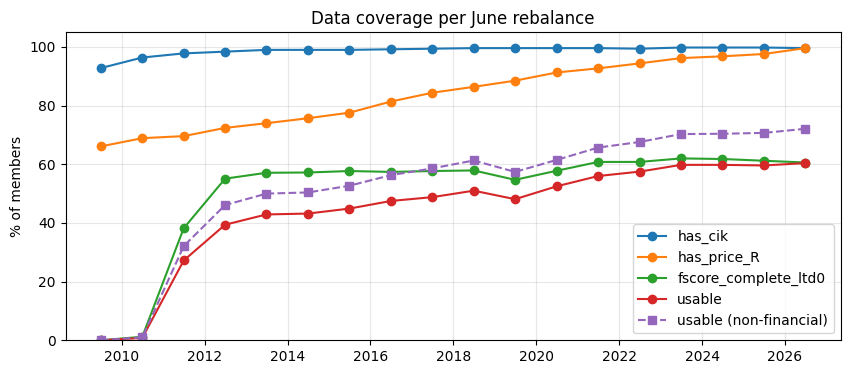

In [16]:
nf = panel[~panel.financial]; fin = panel[panel.financial]
cmp_ = pd.DataFrame({"non-fin members": nf.groupby("R").size(), "non-fin usable %": nf.groupby("R").usable.mean().mul(100).round(1),
                     "fin members": fin.groupby("R").size(), "fin fscore_complete %": fin.groupby("R").fscore_complete_ltd0.mean().mul(100).round(1)})
cmp_.index = cmp_.index.date
print("แยก non-financial vs financial (SIC 6000–6799):"); display(cmp_)
fig, ax = plt.subplots(figsize=(10,4))
for c in ["has_cik","has_price_R","fscore_complete_ltd0","usable"]:
    ax.plot(cov.index, cov[c], marker="o", label=c)
ax.plot(cmp_.index, cmp_["non-fin usable %"], marker="s", ls="--", label="usable (non-financial)")
ax.set_ylim(0, 105); ax.set_ylabel("% of members"); ax.set_title("Data coverage per June rebalance"); ax.legend(); ax.grid(alpha=.3); plt.show()

### 7.1 field ไหนขาดบ่อยที่สุด (non-financial, เฉพาะแถวที่มีงบปี t)

In [17]:
fcols = [c for c in panel.columns if c.startswith("f_")]
miss = (1 - nf[nf.has_fy_t].groupby("R")[fcols].mean()).mul(100).round(1)
miss.index = miss.index.date
display(miss)

,f_net_income,f_cfo,f_total_assets,f_lt_debt,f_current_assets,f_current_liabilities,f_shares,f_revenue,f_gross_profit_any
2009-06-30,0.0,0.0,100.0,100.0,0.0,0.0,0.0,0.0,0.0
2010-06-30,0.4,0.0,97.7,19.0,2.3,2.3,23.6,5.7,30.0
2011-06-30,0.5,0.5,28.3,18.5,2.9,2.9,5.3,6.1,27.8
2012-06-29,0.8,0.0,6.0,16.4,2.8,2.8,1.3,5.3,27.0
2013-06-28,1.2,0.7,2.5,14.7,2.7,3.0,1.5,5.2,27.4
2014-06-30,1.0,0.2,1.7,12.4,2.7,2.7,1.5,4.5,27.3
2015-06-30,0.2,0.0,1.7,11.4,2.5,2.5,1.5,3.5,27.1
2016-06-30,0.5,0.5,2.2,10.9,2.7,2.7,2.0,3.7,27.4
2017-06-30,1.0,0.5,1.2,9.5,2.5,2.5,2.2,4.2,26.7
2018-06-29,0.5,0.3,1.0,9.8,2.8,2.8,2.0,4.5,26.3


### 7.2 สาเหตุที่หุ้นใช้ไม่ได้ (non-financial) — นับแบบลำดับขั้น (waterfall)

In [18]:
def reason(r):
    if not r.has_cik: return "1_no_cik"
    if not r.has_price_R: return "2_no_price"
    if not r.has_fy_t: return "3_no_recent_10k"
    if not r.fscore_complete_ltd0: return "4_fscore_field_missing"
    if not r.bm_complete: return "5_bm_field_missing"
    return "ok"
wf = nf.assign(reason=nf.apply(reason, axis=1)).pivot_table(index="R", columns="reason", values="ticker", aggfunc="count", fill_value=0)
wf.index = wf.index.date
display(wf)

reason,1_no_cik,2_no_price,3_no_recent_10k,4_fscore_field_missing,5_bm_field_missing,ok
2009-06-30,36,126,253,0,0,0
2010-06-30,18,126,81,185,0,4
2011-06-30,11,127,9,132,0,132
2012-06-29,8,118,3,91,2,190
2013-06-28,5,113,4,84,1,207
2014-06-30,5,105,3,91,1,208
2015-06-30,5,96,1,90,2,216
2016-06-30,4,81,0,94,0,231
2017-06-30,3,68,1,96,0,238
2018-06-29,2,57,1,95,1,247


## 8) ปฏิทิน rebalance และช่วง held-out (ตามที่ผู้ใช้ยืนยันหลัง v0 รอบแรก)
held-out = rebalance ตั้งแต่ มิ.ย. 2023 (3 รอบเต็ม: 2023, 2024, 2025) — ห้ามแตะจนกว่าจะสรุป;
รอบ มิ.ย. 2026 ถือได้แค่ถึงข้อมูลล่าสุด → รายงานเป็นข้อมูลประกอบ ไม่นับตัดสิน;
ช่วงตัดสินผ่าน/ไม่ผ่าน in-sample = rebalance 2017–2022 (2011–2016 รายงานประกอบเท่านั้น เพราะ survivorship gap)

In [19]:
cal = pd.DataFrame({"R": Rs})
cal["segment"] = np.select(
    [cal.R < "2011-01-01", cal.R < "2017-01-01", cal.R < "2023-01-01", cal.R < "2026-01-01"],
    ["unusable (no XBRL history)", "in-sample: info only", "in-sample: decision", "held-out: decision"],
    "held-out: info only (partial year)")
cal["hold_until"] = [min(r + pd.DateOffset(years=1), adj.index.max()) for r in cal.R]
cal["hold_days"] = [(adj["SPY"].loc[r:h].notna().sum()) for r, h in zip(cal.R, cal.hold_until)]
cal["usable_nonfin"] = cal.R.map(nf.groupby("R").usable.sum())
cal["R"] = cal.R.dt.date; cal["hold_until"] = cal.hold_until.dt.date
display(cal)

,R,segment,hold_until,hold_days,usable_nonfin
0,2009-06-30,unusable (no XBRL history),2010-06-30,253,0
1,2010-06-30,unusable (no XBRL history),2011-06-30,254,4
2,2011-06-30,in-sample: info only,2012-06-30,253,132
3,2012-06-29,in-sample: info only,2013-06-29,250,190
4,2013-06-28,in-sample: info only,2014-06-28,252,207
5,2014-06-30,in-sample: info only,2015-06-30,253,208
6,2015-06-30,in-sample: info only,2016-06-30,254,216
7,2016-06-30,in-sample: info only,2017-06-30,253,231
8,2017-06-30,in-sample: decision,2018-06-30,252,238
9,2018-06-29,in-sample: decision,2019-06-29,251,247


## 9) สรุปผล v0

> เซลล์นี้ถูกเขียน **หลัง** รันเซลล์ข้างบนแล้ว โดยอ้างตัวเลขจาก output จริงเท่านั้น

In [20]:
s = cov.copy(); s["nonfin_usable"] = cmp_["non-fin usable %"]
summary = {
 "constituents": f"{hist.date.min().date()} → {hist.date.max().date()}",
 "first XBRL 10-K filed": str(first_10k.min().date()),
 "tickers (spells ≥2009)": f"{sp09.ticker.nunique()} ticker / {len(sp09)} spell",
 "cik matched spells": f"{sp_status.mean():.1%}",
 "price coverage (spells ≥2009)": f"{sp09y.has_price.mean():.1%} (ออกแล้ว {sp09y[~still].has_price.mean():.1%})",
 "rebalance: min/median usable% non-fin": f"{s.nonfin_usable.min()} / {s.nonfin_usable.median()}",
}
for k, v in summary.items(): print(f"{k:40s} {v}")

constituents                             1996-01-02 → 2026-08-18
first XBRL 10-K filed                    2009-05-29
tickers (spells ≥2009)                   869 ticker / 894 spell
cik matched spells                       93.2%
price coverage (spells ≥2009)            74.9% (ออกแล้ว 42.7%)
rebalance: min/median usable% non-fin    0.0 / 58.0


## 10) ส่วนเพิ่มตามคำขอหลัง v0 รอบแรก (ใช้กำหนด PREREG ของ v1 — ยังไม่ได้ดูผลตอบแทนใด ๆ)
**10.1 ความพร้อมของสัญญาณ F-score รายข้อ** (non-financial ที่มีงบปี t, นโยบายหนี้หลัก = `evidence`) — จาก `lib/fscore.py`

In [21]:
av = [c for c in panel.columns if c.startswith("av_")]
x = nf[nf.has_fy_t].groupby("R")[av].mean().mul(100).round(1); x.index = x.index.date
display(x)

,av_F_ROA,av_F_CFO,av_F_dROA,av_F_ACCRUAL,av_F_dLEVER,av_F_dLIQUID,av_F_EQ,av_F_dMARGIN,av_F_dTURN
2009-06-30,100.0,100.0,0.0,100.0,0.0,100.0,100.0,100.0,0.0
2010-06-30,99.6,100.0,2.3,99.6,1.5,97.7,75.3,69.6,2.3
2011-06-30,99.5,99.5,71.4,99.2,59.8,97.1,92.6,72.0,67.5
2012-06-29,99.2,99.5,93.7,99.2,78.8,97.2,96.7,73.0,89.4
2013-06-28,98.8,99.0,97.0,98.8,83.6,97.0,97.0,72.6,93.0
2014-06-30,99.3,99.8,97.5,99.3,86.1,97.3,97.5,72.0,94.0
2015-06-30,100.0,100.0,98.3,100.0,87.3,97.5,97.5,72.1,95.0
2016-06-30,99.5,99.5,97.8,99.5,87.7,97.3,96.3,71.6,94.6
2017-06-30,99.5,99.5,98.5,99.3,89.8,97.3,97.0,72.3,95.3
2018-06-29,99.5,99.2,99.0,99.2,89.7,97.0,96.7,72.7,95.2


**10.2 gross margin ขาดกระจุกที่กลุ่มไหน** — ใช้กลุ่มจาก SIC ของ SEC (SEC ไม่มี GICS ย้อนหลัง จึงเป็น proxy) นับเป็น firm-year
(non-financial ที่มีงบปี t, รอบ 2011–2026 และแยกช่วงตัดสิน 2017+)

In [22]:
g = nf[nf.has_fy_t & (nf.R >= "2011-01-01")].copy()
g["sic_group"] = g.sic.map(audit.sic_group)
g["gm_missing"] = ~g.av_F_dMARGIN
def conc(d):
    t = d.groupby("sic_group").agg(firm_years=("gm_missing","size"), gm_missing=("gm_missing","sum"))
    t["pct_missing_in_group"] = (t.gm_missing / t.firm_years * 100).round(1)
    t["share_of_all_missing_%"] = (t.gm_missing / t.gm_missing.sum() * 100).round(1)
    return t.sort_values("gm_missing", ascending=False)
print(f"ทั้งหมด 2011–2026: firm-year {len(g)}, gm ขาด {int(g.gm_missing.sum())} ({g.gm_missing.mean():.1%})")
display(conc(g))
g17 = g[g.R >= "2017-01-01"]
print(f"เฉพาะช่วงตัดสิน 2017+: firm-year {len(g17)}, gm ขาด {int(g17.gm_missing.sum())} ({g17.gm_missing.mean():.1%})")
display(conc(g17).head(10))

ทั้งหมด 2011–2026: firm-year 6420, gm ขาด 1736 (27.0%)


,firm_years,gm_missing,pct_missing_in_group,share_of_all_missing_%
sic_group,,,,
Utilities,564,387,68.6,22.3
Oil & gas extraction,270,233,86.3,13.4
Transportation,266,207,77.8,11.9
Business services & software,763,159,20.8,9.2
Communications,205,110,53.7,6.3
Services (hotels/personal),95,85,89.5,4.9
Petroleum refining,121,79,65.3,4.6
Retail,572,60,10.5,3.5
Construction,97,55,56.7,3.2


เฉพาะช่วงตัดสิน 2017+: firm-year 4033, gm ขาด 1073 (26.6%)


,firm_years,gm_missing,pct_missing_in_group,share_of_all_missing_%
sic_group,,,,
Utilities,347,222,64.0,20.7
Transportation,186,150,80.6,14.0
Oil & gas extraction,119,100,84.0,9.3
Business services & software,538,99,18.4,9.2
Communications,106,76,71.7,7.1
Services (hotels/personal),67,63,94.0,5.9
Machinery & computers,286,46,16.1,4.3
Retail,329,40,12.2,3.7
Transport equipment,146,39,26.7,3.6


**10.3 หนี้ระยะยาว (long-term debt) ที่ไม่มี tag** — กฎที่ผู้ใช้กำหนด: = 0 ได้เฉพาะเมื่อมีหลักฐาน (interest expense ถูกรายงานและ = 0)
นอกนั้น = ไม่ทราบ; ตารางนับ firm-year ตามสถานะหนี้ของงบปี t (non-financial ที่มีงบปี t)

In [23]:
h = nf[nf.has_fy_t & (nf.R >= "2011-01-01")]
ct_ = pd.crosstab(h.R.dt.year, h.ltd_status_t, margins=True, margins_name="รวม")
display(ct_)
aff = h[(h.ltd_status_t != "reported") | (h.ltd_status_t1 != "reported")]
print(f"firm-year ที่กระทบ (ปี t หรือ t-1 ไม่มี tag หนี้): {len(aff)} จาก {len(h)} ({len(aff)/len(h):.1%})")
print(f"  ในนั้นมีหลักฐานว่าไม่มีหนี้ (zero_by_evidence ในปี t): {int((h.ltd_status_t=='zero_by_evidence').sum())}")
print(f"  ช่วงตัดสิน 2017+: กระทบ {int((aff.R >= '2017-01-01').sum())} จาก {int((h.R >= '2017-01-01').sum())}")
elig = nf.assign(main=nf.has_price_R & nf.bm_complete & (nf.n_sig_evidence >= fscore.MIN_AVAILABLE),
                 ltd_zero=nf.has_price_R & nf.bm_complete & (nf.n_sig_zero >= fscore.MIN_AVAILABLE))
e = elig.groupby("R")[["main","ltd_zero"]].sum(); e["diff"] = e.ltd_zero - e.main; e.index = e.index.date
print("\nจำนวนหุ้นที่เข้าเกณฑ์ใช้ใน v1 (มีราคา + BM + สัญญาณ >= 8/9): นโยบายหลัก vs หนี้ที่ขาด = 0")
display(e)

ltd_status_t,reported,unknown_has_interest,unknown_no_interest_tag,zero_by_evidence,รวม
R,,,,,
2011,312,40,26,0,378
2012,337,39,20,1,397
2013,346,35,20,1,402
2014,354,30,19,0,403
2015,357,28,16,1,402
2016,363,23,18,1,405
2017,364,21,16,0,401
2018,362,18,19,0,399
2019,357,22,19,1,399


firm-year ที่กระทบ (ปี t หรือ t-1 ไม่มี tag หนี้): 757 จาก 6420 (11.8%)
  ในนั้นมีหลักฐานว่าไม่มีหนี้ (zero_by_evidence ในปี t): 5
  ช่วงตัดสิน 2017+: กระทบ 423 จาก 4033

จำนวนหุ้นที่เข้าเกณฑ์ใช้ใน v1 (มีราคา + BM + สัญญาณ >= 8/9): นโยบายหลัก vs หนี้ที่ขาด = 0


,main,ltd_zero,diff
2009-06-30,0,0,0
2010-06-30,4,4,0
2011-06-30,168,173,5
2012-06-29,237,245,8
2013-06-28,258,265,7
2014-06-30,266,272,6
2015-06-30,275,280,5
2016-06-30,292,299,7
2017-06-30,300,306,6
2018-06-29,308,315,7


**10.4 IR และ JEF (override ความมั่นใจ medium)** — firm-year ที่กระทบ (จะรัน sensitivity ตัดออกใน v1 ตาม PREREG)

In [24]:
ij = elig[elig.ticker.isin(["IR", "JEF"]) & elig.main]
print(f"firm-year ของ IR/JEF ที่เข้าเกณฑ์ใช้ใน v1: {len(ij)} (IR {int((ij.ticker=='IR').sum())}, JEF {int((ij.ticker=='JEF').sum())})"
      f" จากทั้งหมด {int(elig.main.sum())} ({len(ij)/elig.main.sum():.2%})")
display(ij[["R","ticker","cik"]].assign(R=lambda d: d.R.dt.date).reset_index(drop=True))

firm-year ของ IR/JEF ที่เข้าเกณฑ์ใช้ใน v1: 16 (IR 16, JEF 0) จากทั้งหมด 4900 (0.33%)


,R,ticker,cik
0,2011-06-30,IR,1466258.0
1,2012-06-29,IR,1466258.0
2,2013-06-28,IR,1466258.0
3,2014-06-30,IR,1466258.0
4,2015-06-30,IR,1466258.0
5,2016-06-30,IR,1466258.0
6,2017-06-30,IR,1466258.0
7,2018-06-29,IR,1466258.0
8,2019-06-28,IR,1466258.0
9,2020-06-30,IR,1699150.0


**10.5 ปีเริ่มต้นของราคา benchmark และช่วงที่เทียบได้** (ผู้ใช้ขอให้เทียบเฉพาะช่วงที่มีข้อมูลจริง)

In [25]:
first_R = min(r for r in Rs if nf[nf.R == r].usable.sum() > 0 and r >= pd.Timestamp("2011-01-01"))
b = bm.copy()
b["first"] = pd.to_datetime(b["first"])
b["covers_2011_06"] = b["first"] <= pd.Timestamp("2011-06-30")
b["covers_2017_06"] = b["first"] <= pd.Timestamp("2017-06-30")
display(b[["ticker","currency","first","last","n_days","covers_2011_06","covers_2017_06"]])
usable_b = b[(b.n_days > 250)]
common_start = usable_b["first"].max(); common_end = pd.to_datetime(usable_b["last"]).min()
print(f"benchmark ที่ใช้ได้ (มีข้อมูล > 250 วัน): {list(usable_b.ticker)}")
print(f"ช่วงที่ทุกตัวมีข้อมูลร่วมกัน: {common_start.date()} → {common_end.date()}")

,ticker,currency,first,last,n_days,covers_2011_06,covers_2017_06
0,SPY,USD,2008-01-02,2026-09-25,4713,True,True
1,RSP,USD,2008-01-02,2026-09-25,4713,True,True
2,^GSPC,USD (index pts),2008-01-02,2026-09-25,4713,True,True
3,^DJI,USD (index pts),2008-01-02,2026-09-25,4713,True,True
4,^SET.BK,THB (index pts),2026-09-25,2026-09-25,1,False,False
5,TDEX.BK,THB,2008-01-02,2026-09-24,4565,True,True
6,THD,USD,2008-04-01,2026-09-25,4652,True,True
7,THB=X,THB per USD,2008-01-01,2026-09-25,4859,True,True


benchmark ที่ใช้ได้ (มีข้อมูล > 250 วัน): ['SPY', 'RSP', '^GSPC', '^DJI', 'TDEX.BK', 'THD', 'THB=X']
ช่วงที่ทุกตัวมีข้อมูลร่วมกัน: 2008-04-01 → 2026-09-24


### สรุป v0 (ตัวเลขจากการรันด้านบนทั้งหมด)

**1. ข้อมูลครอบคลุมอะไรบ้าง**
| ส่วน | ผล |
|---|---|
| รายชื่อสมาชิก (fja05680 @ `a2430f2af0`) | 1996-01-02 → 2026-08-18, ตั้งแต่ 2009 มี 869 ticker / 894 spell, สมาชิกต่อวัน 496–507 |
| XBRL 10-K ฉบับแรก | filed 2009-05-29; บริษัทส่วนใหญ่เริ่มปี 2010 (377) และ 2011 (227) |
| จับคู่ ticker → CIK | 833/894 spell (93.2%) — 30 segment ใช้ override ที่มีหลักฐาน SEC, 41 segment CIK เปลี่ยนกลาง spell |
| ราคา (ticker ตาม fja เท่านั้น) | 74.9% ของ spell มีราคา แต่หุ้นที่ออกจากดัชนีแล้วมีแค่ 42.7% |
| Benchmark | SPY, RSP, ^GSPC, ^DJI ครบ 2008→2026 (USD) — **^SET.BK ไม่มีประวัติใน Yahoo** ต้องใช้ proxy TDEX.BK (THB) หรือ THD (USD) |

**2. ช่วงเวลาที่ใช้ได้จริง** — รอบ มิ.ย. 2009 และ 2010 ใช้ไม่ได้ (non-financial usable 0% และ 1%) เพราะยังไม่มีงบ XBRL ย้อนหลังพอสำหรับ F-score
รอบแรกที่ใช้ได้คือ **มิ.ย. 2011** (non-financial usable 32.1%) และ 46–72% ตั้งแต่ 2012 เป็นต้นไป

**3. ช่องว่างหลัก (non-financial, ดู waterfall 7.2)**
- **ไม่มีราคา (survivorship)**: 127 ตัวในรอบ 2011, 96 ตัวในรอบ 2015, 47 ตัวในรอบ 2019 — ลดลงเรื่อย ๆ เพราะหุ้นที่ยังอยู่ถึงปัจจุบันมีราคาครบ
  ⇒ **ช่วงต้น (2011–2016) ขาดราคาราว 20–31% ของสมาชิก** → ผลช่วงนี้มี survivorship bias สูงสุด
- **field ของ F-score ไม่ครบ**: ตัวหลักคือ gross margin (ขาด 25–31% ของหุ้นที่มีงบ) เพราะบริษัทบริการ/utility/พลังงานหลายแห่งไม่รายงาน gross profit หรือ COGS
  รองลงมาคือ long-term debt (ขาด 9–19%) ซึ่งส่วนหนึ่งอาจเป็นบริษัทที่ไม่มีหนี้ระยะยาวจริง
- **กลุ่มการเงิน (SIC 6000–6799)**: F-score ครบแค่ 3.5–14.7% ตามคาด (ไม่มี current assets/liabilities/gross profit) → ต้องใช้กฎแยกตาม SPEC

**4. Point-in-time ตรวจแล้ว**
- ค่าที่ถูกแก้ย้อนหลังมีจริง 6–18% ของ (บริษัท, field, งวด) ขึ้นกับ field → ยืนยันว่าการใช้ค่าที่ filed ครั้งแรกมีผล
- บั๊กที่พบและแก้ใน v0: การเลือก tag ก่อนดูวันที่ทำให้งบปี 2017 "หายไป" ในรอบ มิ.ย. 2018 → แก้ด้วย `lib/pit.py` (เลือก tag ทีละ field เฉพาะที่ filed แล้ว)

**5. ข้อจำกัด**
- ราคาจาก Yahoo ไม่มีหุ้นที่ถูกซื้อ/ล้มละลายส่วนใหญ่ → ผลตอบแทนมีแนวโน้มสูงเกินจริง (survivorship)
- จำนวนหุ้นจาก SEC มีข้อมูลผิดบ้าง (scale ผิด, BRK รายงานเป็น Class A equivalent) — 0–3 ตัวต่อรอบถูก flag และไม่ใช้คำนวณ market cap
- การจับคู่ CIK ใช้ heuristic + override: override ระดับ `medium` 2 รายการ (IR หลัง 2020-03, JEF 2007–2019) ยังไม่มั่นใจเต็มร้อย
- AGN รอบ มิ.ย. 2015 ยังใช้งบของ Allergan Inc (ถูกซื้อไปเมื่อ มี.ค. 2015) — ความคลาดเคลื่อนระดับ 1 บริษัท-ปี
- Held-out มีแค่ 3 รอบเต็ม (มิ.ย. 2023, 2024, 2025) + รอบ 2026 ที่ถือได้ 62 วันทำการ → ความไม่แน่นอนสูง

**6. ส่วนเพิ่มหลัง v0 รอบแรก (หัวข้อ 10)**
- gross margin ขาด 27.0% ของ firm-year (2011–2026; 26.6% ในช่วง 2017+) กระจุกที่ Utilities (22.3% ของที่ขาดทั้งหมด), Oil & gas extraction (13.4%),
  Transportation (11.9%), Business services & software (9.2%) — ภายในกลุ่ม utilities ขาด 68.6%, oil & gas 86.3% (จัดกลุ่มด้วย SIC ไม่ใช่ GICS)
- หนี้ระยะยาว: firm-year ที่ปี t หรือ t-1 ไม่มี tag หนี้ = 757/6,420 (11.8%) แต่มีหลักฐานว่าไม่มีหนี้จริง (interest expense = 0) แค่ 5 firm-year
  ที่เหลือส่วนใหญ่ยังรายงาน interest expense > 0 (388) → น่าจะมีหนี้แต่ใช้ tag อื่น → "ไม่ทราบ" ตามกฎ
- หุ้นที่เข้าเกณฑ์ v1 (ราคา + BM + สัญญาณ ≥ 8/9, non-financial): 168 (2011) → 300 (2017) → 375 (2026); ถ้าถือหนี้ที่ขาด = 0 เพิ่มได้ 5–12 ตัวต่อรอบ
- IR/JEF: กระทบ 16 firm-year (0.33%) ทั้งหมดเป็น IR; JEF ไม่อยู่ใน universe เพราะ SIC เป็นกลุ่มการเงิน
- benchmark ทุกตัว (ยกเว้น ^SET.BK) มีข้อมูลตั้งแต่ก่อน มิ.ย. 2011 — ช่วงร่วมกัน 2008-04-01 → 2026-09-24
- assertion กันบั๊กเงียบ (`lib/checks.py`) ผ่านทั้งหมด และทดสอบแล้วว่าจับหลุมแบบบั๊ก 2018 ที่จำลองขึ้นได้
- รันใหม่หลังแก้บั๊กราคา 2 จุดที่พบระหว่าง v1 (ปรับจำนวนหุ้นด้วย split ระหว่างวันนับหุ้นกับ R; ใช้ ticker ปัจจุบันของ CIK ก่อน ticker ตาม fja)
  → ตัวเลขข้างบนเปลี่ยนเล็กน้อย (เช่น หุ้นที่เข้าเกณฑ์รอบ 2017 จาก 299 เป็น 300)

**ทดสอบแล้ว (รันจริงใน notebook นี้)**: ความครอบคลุมทุกส่วนข้างบน, การจับคู่ CIK (สุ่มตรวจ + ตรวจขนาดบริษัท), ตรวจ ticker reuse ด้วยราคาจริง, สถิติ restatement
**ยังเป็นแค่ไอเดีย (ยังไม่ได้ทำ)**: หาแหล่งราคาหุ้นที่ delist แล้ว, การคำนวณ F-score/BM จริงและ backtest ทุกแบบ รวมถึง sensitivity (ล็อกไว้ใน `PREREG.md` สำหรับ v1)